In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]

/home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare


In [2]:
imgNetF = loc / "alexnet_1000_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_file.append(file_path)
        



Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/alexnet_1000_data/inat_alexnet_1000_npclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performanceCompare/alexnet_1000_data/inat_alexnet_1000_ptclasses_imagenet_history.json


In [3]:

json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name_pth = {
    "inat_alexnet_1000_ptclasses_imagenet.pth": "AlexNet pretrained model",
    "inat_alexnet_1000_npclasses_imagenet.pth": "AlexNet random start model",
}

# derive the equivalent mapping keyed by history-json filename
model_name = {
    Path(pth_name).stem + "_history.json": label
    for pth_name, label in model_name_pth.items()
}

assert len(model_name.keys()) == len(json_file), (
    f"Expected {len(model_name)} json files, found {len(json_file)}: "
    f"{[f.name for f in json_file]}"
)

inat_alexnet_1000_npclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50], 'train_loss': [6.842443964767456, 6.575846579742431, 6.308276747894287, 6.125061822891236, 5.941790497970581, 5.7320195648193355, 5.517338038253784, 5.3124636417388915, 5.112183317184448, 4.91544264793396, 4.729293481063843, 4.532325329589844, 4.342229656028747, 4.13694721660614, 3.9250708683013915, 3.7137024478912353, 3.511728503608704, 3.307502618598938, 3.1178926805496214, 2.929011912918091, 2.7616045150756836, 2.6047861822128295, 2.467833869457245, 2.154892419052124, 2.0569233724594116, 2.0004600359916687, 1.9360763509750367, 1.8153357506752015, 1.7735734809875487, 1.743405042743683, 1.7214453915596009, 1.6999855637550354, 1.6781083669662475, 1.6628134696006776, 1.6405280393600463, 1.6242764176368714, 1.606614912891388, 1.59173079900

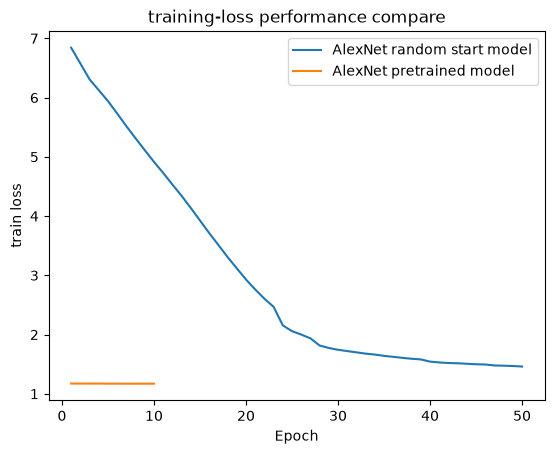

In [4]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]["epoch"], json_data[dt]["train_loss"], label=model_name[json_file[dt].name], linestyle='-')

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("training-loss performance compare")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

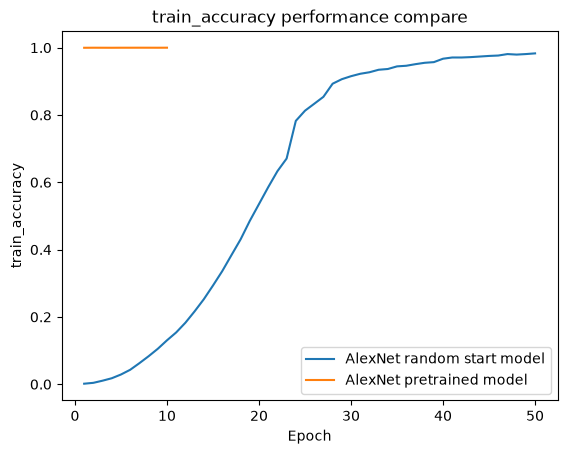

In [5]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train_accuracy")
plt.title("train_accuracy performance compare")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

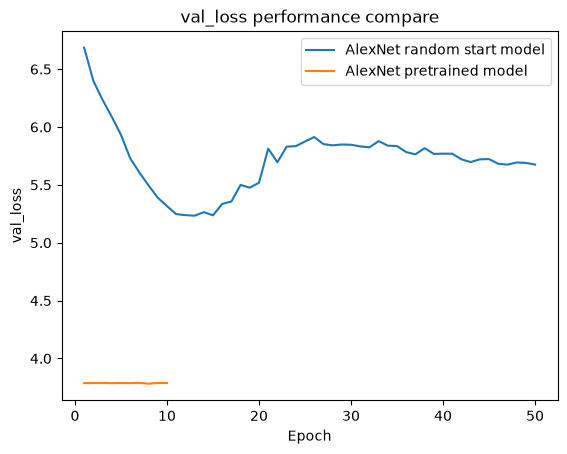

In [6]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.title("val_loss performance compare")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

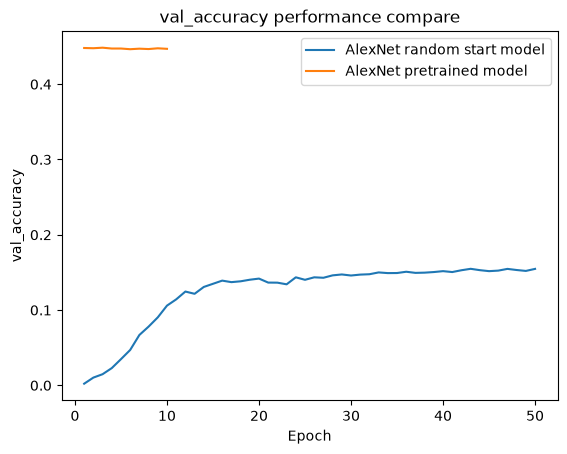

In [7]:
# train acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.title("val_accuracy performance compare")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

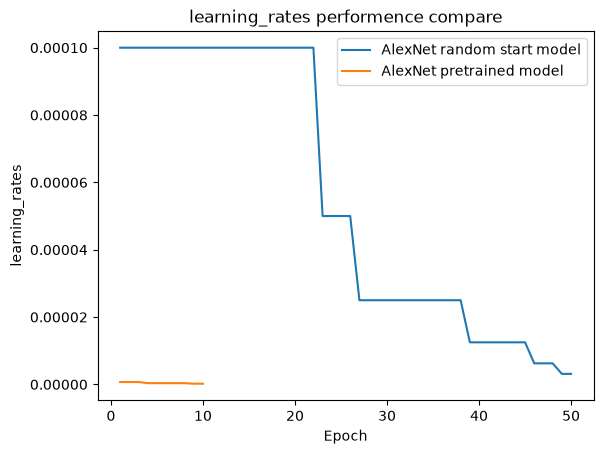

In [8]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("learning_rates")
plt.title("learning_rates performence compare")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib